# Phase 3 Step 2 — Leakage-Safe Return-Risk Baselines

This notebook uses Complete Journey 2.0 grocery-household data. Positive class `return_risk_target=1` means **zero distinct baskets in `(T,T+28 days]`**, not contractual churn. It trains only on April–August 2017 and evaluates the same fitted baselines on September and October separately and pooled. **November lockbox outcomes are never loaded or labeled.**

## Problem definition and target semantics

One row is one eligible household at one month-end snapshot. Features end at `T`; the target begins strictly after `T`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd, pyreadr, matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve
from marketmind.return_risk.cohorts import build_labeled_cohort
from marketmind.return_risk.features import (build_candidate_features, baseline_features,
    make_logistic_preprocessor, CANDIDATE_FEATURE_ORDER, BASELINE_FEATURE_ORDER)
from marketmind.return_risk.evaluation import (score_metrics, capacity_metrics,
    calibration_bins, clustered_bootstrap_auc)
pd.set_option('display.max_columns', 40)
RAW = ROOT/'data'/'raw'/'complete_journey'
ART = ROOT/'reports'/'return_risk'/'artifacts'; FIG = ROOT/'reports'/'return_risk'/'figures'
ART.mkdir(parents=True, exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


## Temporal cohorts

Training snapshots are April–August. Validation A is September and Validation B is October. The November 30 lockbox is absent from the snapshot constant and guarded by assertions.

In [2]:
TRAIN_SNAPSHOTS = pd.to_datetime(['2017-04-30 23:59:59','2017-05-31 23:59:59',
    '2017-06-30 23:59:59','2017-07-31 23:59:59','2017-08-31 23:59:59'])
VALID_SNAPSHOTS = pd.to_datetime(['2017-09-30 23:59:59','2017-10-31 23:59:59'])
SNAPSHOTS = TRAIN_SNAPSHOTS.append(VALID_SNAPSHOTS)
assert SNAPSHOTS.max() == pd.Timestamp('2017-10-31 23:59:59')
assert pd.Timestamp('2017-11-30 23:59:59') not in SNAPSHOTS
transactions = pyreadr.read_r(str(RAW/'transactions.rds'))[None]
products = pyreadr.read_r(str(RAW/'products.rda'))['products']
transactions['transaction_timestamp'] = pd.to_datetime(transactions.transaction_timestamp)
frames=[]
for snapshot in SNAPSHOTS:
    features=build_candidate_features(transactions,products,snapshot)
    labels=build_labeled_cohort(transactions,snapshot,28,'2017-12-31 23:59:59')[['return_risk_target']]
    frame=features.join(labels,validate='one_to_one').reset_index()
    frame['snapshot_at']=snapshot; frames.append(frame)
data=pd.concat(frames,ignore_index=True)
train=data[data.snapshot_at.isin(TRAIN_SNAPSHOTS)].copy()
validation=data[data.snapshot_at.isin(VALID_SNAPSHOTS)].copy()
train.groupby('snapshot_at').return_risk_target.agg(['size','sum','mean']), validation.groupby('snapshot_at').return_risk_target.agg(['size','sum','mean'])

(                     size  sum      mean
 snapshot_at                             
 2017-04-30 23:59:59  1777  125  0.070343
 2017-05-31 23:59:59  1970  192  0.097462
 2017-06-30 23:59:59  2085  219  0.105036
 2017-07-31 23:59:59  2172  269  0.123849
 2017-08-31 23:59:59  2219  311  0.140153,
                      size  sum      mean
 snapshot_at                             
 2017-09-30 23:59:59  2247  310  0.137962
 2017-10-31 23:59:59  2282  315  0.138037)

## Feature design and training-only audit

Candidate features cover RFM, recent activity, cadence, engagement, product/category behavior, promotion associations, and 28-day changes. Redundancy decisions use only training features—never validation outcomes.

In [3]:
audit=train[list(CANDIDATE_FEATURE_ORDER)].agg(['median','skew']).T
audit['missing_pct']=train[list(CANDIDATE_FEATURE_ORDER)].isna().mean()*100
audit['zero_pct']=train[list(CANDIDATE_FEATURE_ORDER)].eq(0).mean()*100
for q in (.05,.25,.75,.95): audit[f'p{int(q*100):02d}']=train[list(CANDIDATE_FEATURE_ORDER)].quantile(q)
audit=audit[['missing_pct','zero_pct','median','p05','p25','p75','p95','skew']]
audit.to_csv(ART/'feature_audit.csv')
corr=train[list(CANDIDATE_FEATURE_ORDER)].corr(method='spearman')
pairs=corr.abs().where(np.triu(np.ones(corr.shape),1).astype(bool)).stack().sort_values(ascending=False)
display(audit.round(3)); display(pairs.head(20).rename('absolute_spearman'))

,missing_pct,zero_pct,median,p05,p25,p75,p95,skew
recency_days,0.0,16.717,4.000,0.000,1.000,12.000,42.000,3.665
basket_frequency_lifetime,0.0,0.000,26.000,6.000,13.000,46.000,106.900,3.999
monetary_lifetime,0.0,0.000,739.640,110.430,335.830,1435.360,3267.833,2.582
average_basket_value,0.0,0.000,27.337,9.097,18.004,41.284,72.372,1.971
baskets_last_7d,0.0,38.335,1.000,0.000,0.000,2.000,5.000,2.951
baskets_last_14d,0.0,21.804,2.000,0.000,1.000,4.000,9.000,3.253
baskets_last_28d,0.0,9.332,4.000,0.000,2.000,7.000,17.000,3.568
baskets_last_56d,0.0,2.807,8.000,1.000,4.000,15.000,33.000,3.618
spend_last_28d,0.0,9.371,107.290,0.000,33.750,235.545,538.499,2.292
spend_last_56d,0.0,2.817,222.850,10.340,86.845,461.005,1036.983,2.292


basket_frequency_lifetime    active_days                    0.991801
monetary_lifetime            unique_products                0.946064
active_days                  active_weeks                   0.944876
basket_frequency_lifetime    mean_days_between_baskets      0.942360
                             active_weeks                   0.929865
mean_days_between_baskets    std_days_between_baskets       0.928002
                             active_days                    0.927055
baskets_last_28d             baskets_last_56d               0.923787
spend_last_28d               spend_last_56d                 0.917352
median_days_between_baskets  mean_days_between_baskets      0.917105
active_span_days             active_months                  0.898595
baskets_last_14d             baskets_last_28d               0.888009
std_days_between_baskets     active_days                    0.874641
basket_frequency_lifetime    std_days_between_baskets       0.866776
baskets_last_56d             mean_

### Frozen baseline feature set

The training audit removes exact duplicate `days_since_last_basket`, `baskets_last_14d`, `baskets_last_56d`, `spend_last_56d`, mean cadence, active days/weeks/months, unique products, and discounted-basket rate. Reasons are exact semantics, strong empirical/conceptual redundancy, or limited incremental interpretation. The final ordered set is shown below.

In [4]:
pd.Series(BASELINE_FEATURE_ORDER, name='feature')

0                    recency_days
1       basket_frequency_lifetime
2               monetary_lifetime
3            average_basket_value
4                 baskets_last_7d
5                baskets_last_28d
6                  spend_last_28d
7     median_days_between_baskets
8        std_days_between_baskets
9                active_span_days
10             unique_departments
11           department_spend_hhi
12        discount_share_of_gross
13             coupon_basket_rate
14             baskets_28d_change
15               spend_28d_change
Name: feature, dtype: str

## Preprocessing

Nonnegative skewed magnitudes receive fixed `log1p`; signed change and bounded ratio features remain unchanged. A `RobustScaler` is fit on April–August only inside each Logistic pipeline.

In [5]:
X_train=baseline_features(train); y_train=train.return_risk_target
X_valid=baseline_features(validation); y_valid=validation.return_risk_target
preprocessor=make_logistic_preprocessor().fit(X_train)
assert np.allclose(preprocessor.named_steps['scale'].center_, preprocessor.named_steps['log1p'].transform(X_train).median())

## Behavioral baselines

Recency is converted to a bounded training empirical-rank score. The exactly-one heuristic is predeclared as `sigmoid(z(recency) - z(log1p(lifetime baskets)))`, with equal untuned weights and training-only location/scale.

In [6]:
recency_sorted=np.sort(train.recency_days.to_numpy())
def recency_score(values): return np.searchsorted(recency_sorted,np.asarray(values),side='right')/len(recency_sorted)
log_frequency=np.log1p(train.basket_frequency_lifetime)
rmean,rstd=train.recency_days.mean(),train.recency_days.std(ddof=0)
fmean,fstd=log_frequency.mean(),log_frequency.std(ddof=0)
def heuristic_score(frame):
    return expit((frame.recency_days-rmean)/rstd-(np.log1p(frame.basket_frequency_lifetime)-fmean)/fstd)
scores={'recency_rule':recency_score(validation.recency_days),
        'recency_frequency_heuristic':heuristic_score(validation)}

## Logistic Regression and class imbalance

Exactly two fixed variants are trained: unweighted and `class_weight='balanced'`. Both use `lbfgs`, `max_iter=2000`, default `C`, and random state 42. There is no tuning or resampling.

In [7]:
models={}
for name,class_weight in [('logistic_unweighted',None),('logistic_balanced','balanced')]:
    model=Pipeline([('preprocess',make_logistic_preprocessor()),
        ('model',LogisticRegression(class_weight=class_weight,solver='lbfgs',max_iter=2000,random_state=42))])
    model.fit(X_train,y_train); models[name]=model
    scores[name]=model.predict_proba(X_valid)[:,1]
assert all(m.named_steps['model'].n_iter_[0] < 2000 for m in models.values())

## Validation results and temporal stability

PR-AUC is primary; its no-skill context is prevalence. Threshold 0.5 metrics are diagnostic only. Behavioral scores are bounded scores, not calibrated probability estimates, so their log loss/Brier values are descriptive scale diagnostics only.

In [8]:
rows=[]
for name,score in scores.items():
    for cohort,date in [('September','2017-09-30'),('October','2017-10-31'),('Pooled',None)]:
        mask=np.ones(len(validation),bool) if date is None else validation.snapshot_at.dt.date==pd.Timestamp(date).date()
        result=score_metrics(y_valid[mask],np.asarray(score)[mask]); rows.append({'model':name,'cohort':cohort,**result})
metrics=pd.DataFrame(rows); metrics.to_csv(ART/'baseline_metrics.csv',index=False)
display(metrics.drop(columns='confusion_matrix').round(4))

,model,cohort,n,prevalence,pr_auc,roc_auc,log_loss,brier,precision_at_0_5,recall_at_0_5,f1_at_0_5
0,recency_rule,September,2247,0.138,0.4355,0.7829,0.9270,0.3087,0.2085,0.8677,0.3362
1,recency_rule,October,2282,0.138,0.4303,0.7918,0.9286,0.3013,0.2159,0.8603,0.3452
2,recency_rule,Pooled,4529,0.138,0.4316,0.7870,0.9278,0.3050,0.2122,0.8640,0.3407
3,recency_frequency_heuristic,September,2247,0.138,0.4864,0.8537,0.6615,0.1977,0.3165,0.8290,0.4581
4,recency_frequency_heuristic,October,2282,0.138,0.4563,0.8394,0.6597,0.1901,0.3268,0.7905,0.4624
5,recency_frequency_heuristic,Pooled,4529,0.138,0.4688,0.8459,0.6606,0.1939,0.3215,0.8096,0.4602
6,logistic_unweighted,September,2247,0.138,0.4773,0.8591,0.2915,0.0904,0.5915,0.2710,0.3717
7,logistic_unweighted,October,2282,0.138,0.4471,0.8426,0.3044,0.0952,0.4928,0.2159,0.3002
8,logistic_unweighted,Pooled,4529,0.138,0.4586,0.8508,0.2980,0.0929,0.5429,0.2432,0.3359
9,logistic_balanced,September,2247,0.138,0.4714,0.8588,0.5357,0.1790,0.3292,0.8645,0.4769


## Calibration diagnostics

These plots diagnose uncalibrated Logistic estimates on development validation. No Platt or isotonic calibrator is fit.

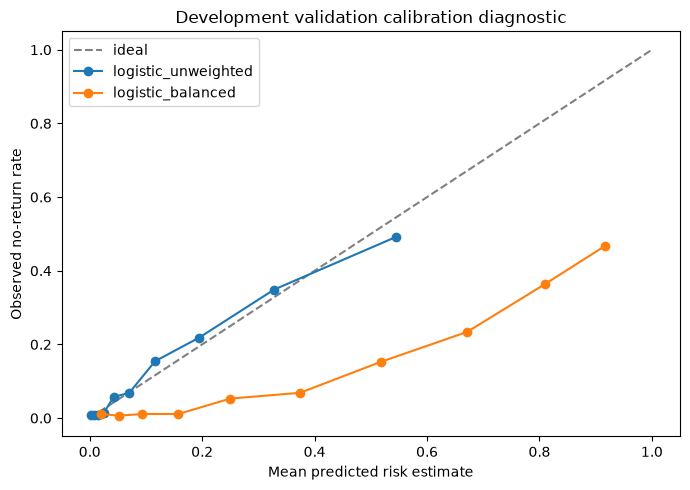

,mean_score,observed_rate,model
0,0.0029,0.0088,logistic_unweighted
1,0.0078,0.0088,logistic_unweighted
2,0.0146,0.0088,logistic_unweighted
3,0.0249,0.0132,logistic_unweighted
4,0.0424,0.0574,logistic_unweighted
5,0.0704,0.0686,logistic_unweighted
6,0.1163,0.1545,logistic_unweighted
7,0.1949,0.2185,logistic_unweighted
8,0.3278,0.3488,logistic_unweighted
9,0.5456,0.4923,logistic_unweighted


In [9]:
cal=[]
fig,ax=plt.subplots(figsize=(7,5))
ax.plot([0,1],[0,1],'--',color='grey',label='ideal')
for name in ('logistic_unweighted','logistic_balanced'):
    bins=calibration_bins(y_valid,scores[name],10).assign(model=name); cal.append(bins)
    ax.plot(bins.mean_score,bins.observed_rate,marker='o',label=name)
ax.set(xlabel='Mean predicted risk estimate',ylabel='Observed no-return rate',title='Development validation calibration diagnostic')
ax.legend(); fig.tight_layout(); fig.savefig(FIG/'baseline_calibration.png',dpi=160); plt.show()
calibration=pd.concat(cal,ignore_index=True); calibration.to_csv(ART/'calibration_bins.csv',index=False); display(calibration.round(4))

## Threshold and capacity exploration

The unweighted Logistic variant has the higher pooled Logistic PR-AUC. No threshold is frozen. Top-fraction metrics simulate limited capacity only.

,capacity,selected,positives_captured,precision,recall
0,0.05,227,129,0.5683,0.2064
1,0.10,453,223,0.4923,0.3568
2,0.20,906,381,0.4205,0.6096


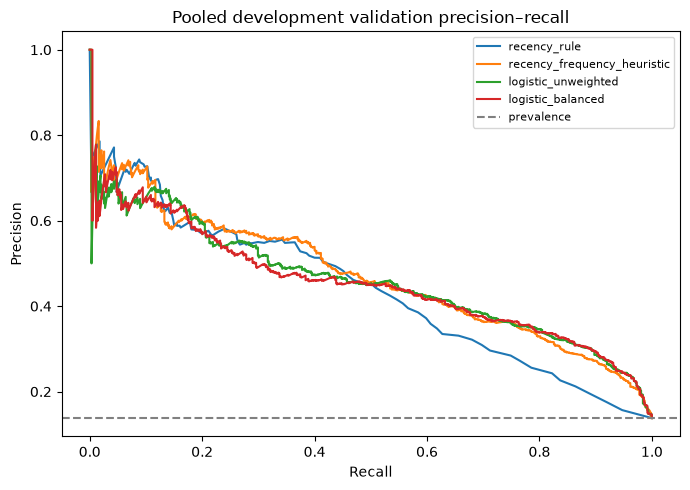

In [10]:
best='logistic_unweighted'
capacity=capacity_metrics(y_valid,scores[best]); capacity.to_csv(ART/'capacity_metrics.csv',index=False); display(capacity.round(4))
fig,ax=plt.subplots(figsize=(7,5))
for name,score in scores.items():
    precision,recall,_=precision_recall_curve(y_valid,score); ax.plot(recall,precision,label=name)
ax.axhline(y_valid.mean(),ls='--',color='grey',label='prevalence')
ax.set(xlabel='Recall',ylabel='Precision',title='Pooled development validation precision–recall'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG/'baseline_precision_recall.png',dpi=160); plt.show()

## Household-clustered uncertainty

A deterministic 300-replicate bootstrap resamples households, retaining their repeated rows. This avoids treating pooled snapshots as IID.

In [11]:
intervals={}
for name in ('logistic_unweighted','logistic_balanced'):
    intervals[name]=clustered_bootstrap_auc(validation.assign(score=scores[name]),household_column='household_id',target_column='return_risk_target',score_column='score',n_bootstrap=300)
pd.DataFrame(intervals).T

,pr_auc_95ci,roc_auc_95ci
logistic_unweighted,"(0.41043489970138036, 0.503774512019259)","(0.8319883253649359, 0.8664455593115367)"
logistic_balanced,"(0.40606121347452406, 0.49825418558593143)","(0.8311084250664906, 0.8651572358908052)"


## Error analysis

The 0.5 cutoff is a diagnostic lens, not an operational choice. Group medians are associations, not causal effects.

In [12]:
error=validation.copy(); error['score']=scores[best]; error['prediction']=(error.score>=.5).astype(int)
error['error_type']=np.select([(error.return_risk_target.eq(1)&error.prediction.eq(1)),
    (error.return_risk_target.eq(0)&error.prediction.eq(1)),(error.return_risk_target.eq(0)&error.prediction.eq(0))],['TP','FP','TN'],default='FN')
error_summary=error.groupby('error_type')[list(BASELINE_FEATURE_ORDER)].median()
outcome_summary=error.groupby('return_risk_target')[list(BASELINE_FEATURE_ORDER)].median()
error_summary.to_csv(ART/'error_group_medians.csv'); outcome_summary.to_csv(ART/'outcome_group_medians.csv')
display(error.error_type.value_counts()); display(error_summary.round(3)); display(outcome_summary.round(3))

error_type
TN    3776
FN     473
TP     152
FP     128
Name: count, dtype: int64

,recency_days,basket_frequency_lifetime,monetary_lifetime,average_basket_value,baskets_last_7d,baskets_last_28d,spend_last_28d,median_days_between_baskets,std_days_between_baskets,active_span_days,unique_departments,department_spend_hhi,discount_share_of_gross,coupon_basket_rate,baskets_28d_change,spend_28d_change
error_type,,,,,,,,,,,,,,,,
FN,15.0,18.0,460.590,25.009,0.0,1.0,16.960,7.951,13.257,246.0,9.0,0.344,0.153,0.000,0.0,0.000
FP,61.0,8.0,168.735,18.824,0.0,0.0,0.000,16.747,26.696,212.0,7.0,0.368,0.134,0.000,0.0,0.000
TN,3.0,45.0,1281.155,27.714,1.0,4.0,119.275,4.211,5.929,269.0,11.0,0.333,0.150,0.032,0.0,0.505
TP,61.0,7.0,149.765,19.285,0.0,0.0,0.000,14.791,29.504,188.0,6.0,0.396,0.144,0.000,0.0,0.000


,recency_days,basket_frequency_lifetime,monetary_lifetime,average_basket_value,baskets_last_7d,baskets_last_28d,spend_last_28d,median_days_between_baskets,std_days_between_baskets,active_span_days,unique_departments,department_spend_hhi,discount_share_of_gross,coupon_basket_rate,baskets_28d_change,spend_28d_change
return_risk_target,,,,,,,,,,,,,,,,
0,4.0,43.0,1223.875,27.460,1.0,4.0,111.955,4.439,6.127,269.0,11.0,0.334,0.149,0.031,0.0,0.0
1,25.0,15.0,368.250,23.059,0.0,1.0,5.000,9.212,15.747,232.0,8.0,0.347,0.151,0.000,0.0,0.0


## Class imbalance, leakage protections, and limitations

No SMOTE, over/undersampling, random split, segmentation feature, future transaction, or lockbox outcome is used. Class imbalance is handled through PR-AUC context, one balanced-weight diagnostic, and capacity analysis. Repeated snapshots remain dependent. The panel is grocery-specific, short, and cannot establish contractual churn or causal drivers.

## Decision

The recency-frequency heuristic remains the strongest primary-metric baseline. Logistic Regression improves ROC-AUC modestly but does not beat the heuristic on pooled PR-AUC. Unweighted Logistic is preferred to balanced Logistic for the next controlled comparison because ranking is slightly stronger and Brier/log loss are substantially better; neither output is called calibrated. The next experiment may compare a narrowly specified nonlinear model after review, without touching November.